# ⚽ World Cup Data Exploration

A guided tour of the data in `data/`. New to the data? Read **[DATA_GUIDE.md](../docs/DATA_GUIDE.md)** first
for a plain-English explanation of every file and football term.

**How to run:** select the `.venv` kernel (top-right), then **Run All**. The notebook is
safe to run top-to-bottom.

---

## Contents

| Part | What it covers |
|---|---|
| **0. Setup** | Imports and configuration |
| **1. What's in the data** | Inventory of all files + how to inspect any one |
| **2. Data-quality checks** | Missing values and the team-name mismatch between sources |
| **3. Insights** | The interesting findings, using clean combined data |

Parts 1–2 look at the **raw** files. Part 3 switches to the **clean loaders** in `src/load.py`,
which fix the country-name mismatches so the two data sources can be combined.

---
# 0. Setup

Import libraries and the project's own helpers. `src.io` reads files safely (right encoding);
`src.load` returns cleaned, name-normalized tables.

In [1]:
import sys
from pathlib import Path

# Make the project root importable regardless of where Jupyter is launched.
_p = Path.cwd()
while not (_p / "src").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src.io import read_csv_safe, human_size, find_csvs, DATA_DIR
from src import load  # clean, name-normalized loaders

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 40)
plt.rcParams["figure.figsize"] = (9, 4)

print("Setup OK — pandas", pd.__version__)

Setup OK — pandas 3.0.3


---
# 1. What's in the data

Two sources sit under `data/`:
- **`kaggle_2026/`** — the up-to-date backbone (World Cup finals, FIFA rankings, 2026 schedule).
- **`maven_analytics/`** — broader history (every international match since 1872) + 2022 squads.

First we list every file; then we load them all and build a tool to inspect any one.

## 1.1 Inventory — one row per file

In [2]:
csvs = find_csvs(DATA_DIR)

rows = []
frames = {}  # cache each raw DataFrame so later cells don't re-read from disk
for path in csvs:
    df, enc = read_csv_safe(path)
    rel = path.relative_to(DATA_DIR)
    frames[rel.as_posix()] = df  # forward-slash key so it matches on Windows too
    rows.append({
        "folder": rel.parts[0],
        "file": rel.name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "size": human_size(path.stat().st_size),
        "encoding": enc,
        "dup_rows": int(df.duplicated().sum()),
        "missing_cells": int(df.isna().sum().sum()),
    })

inventory = pd.DataFrame(rows)
inventory

,folder,file,rows,cols,size,encoding,dup_rows,missing_cells
0,kaggle_2026,fifa_ranking_2022-10-06.csv,211,7,8.6 KB,utf-8,0,0
1,kaggle_2026,fifa_ranking_2026-06-08.csv,211,8,10.9 KB,utf-8,0,0
2,kaggle_2026,matches_1930_2022.csv,964,44,691.3 KB,utf-8,0,20914
3,kaggle_2026,schedule_2026.csv,72,10,4.8 KB,utf-8,0,216
4,kaggle_2026,world_cup.csv,22,9,1.6 KB,utf-8,0,0
5,maven_analytics,2022_world_cup_groups.csv,32,3,478 B,utf-8,0,0
6,maven_analytics,2022_world_cup_matches.csv,64,7,3.2 KB,utf-8,0,16
7,maven_analytics,2022_world_cup_squads.csv,831,10,55.0 KB,cp1252,0,0
8,maven_analytics,data_dictionary.csv,48,3,3.6 KB,utf-8,0,0
9,maven_analytics,international_matches.csv,17769,9,1.1 MB,utf-8,0,17568


## 1.2 Totals by source

In [3]:
inventory.groupby("folder").agg(
    files=("file", "count"),
    total_rows=("rows", "sum"),
    files_with_missing=("missing_cells", lambda s: int((s > 0).sum())),
)

,files,total_rows,files_with_missing
folder,,,
kaggle_2026,5,1480,2
maven_analytics,7,19666,4


## 1.3 Inspect any single file

`profile(name)` renders a file's columns, missing values, first rows and numeric stats as
tables. Pass any name from the inventory above.

In [4]:
def profile(name: str, n: int = 3):
    """Render a per-file profile from the cached raw DataFrames."""
    df = frames[name]
    display(Markdown(f"### `{name}` — {df.shape[0]:,} rows × {df.shape[1]} cols"))

    missing = df.isna().sum()
    overview = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": missing,
        "missing_%": (missing / len(df) * 100).round(1) if len(df) else 0,
        "n_unique": df.nunique(dropna=True),
    })
    display(Markdown("**Columns**"))
    display(overview)
    display(Markdown(f"**First {n} rows**"))
    display(df.head(n))

    num = df.select_dtypes("number")
    if not num.empty:
        display(Markdown("**Numeric summary**"))
        display(num.describe().round(2))


# Names you can pass to profile():
list(frames)

['kaggle_2026/fifa_ranking_2022-10-06.csv',
 'kaggle_2026/fifa_ranking_2026-06-08.csv',
 'kaggle_2026/matches_1930_2022.csv',
 'kaggle_2026/schedule_2026.csv',
 'kaggle_2026/world_cup.csv',
 'maven_analytics/2022_world_cup_groups.csv',
 'maven_analytics/2022_world_cup_matches.csv',
 'maven_analytics/2022_world_cup_squads.csv',
 'maven_analytics/data_dictionary.csv',
 'maven_analytics/international_matches.csv',
 'maven_analytics/world_cup_matches.csv',
 'maven_analytics/world_cups.csv']

Change the name below to inspect a different file. The two richest files are the kaggle
World Cup matches and the Maven international-matches history.

In [5]:
profile("kaggle_2026/matches_1930_2022.csv")

### `kaggle_2026/matches_1930_2022.csv` — 964 rows × 44 cols

**Columns**

,dtype,non_null,missing,missing_%,n_unique
home_team,str,964,0,0.0,82
away_team,str,964,0,0.0,86
home_score,int64,964,0,0.0,11
home_xg,float64,128,836,86.7,35
home_penalty,float64,35,929,96.4,6
away_score,int64,964,0,0.0,7
away_xg,float64,128,836,86.7,31
away_penalty,float64,35,929,96.4,6
home_manager,str,964,0,0.0,329
home_captain,str,644,320,33.2,280


**First 3 rows**

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,away_manager,away_captain,Attendance,Venue,Officials,Round,Date,Score,Referee,Notes,Host,Year,home_goal,away_goal,home_goal_long,away_goal_long,home_own_goal,away_own_goal,home_penalty_goal,away_penalty_goal,home_penalty_miss_long,away_penalty_miss_long,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,Didier Deschamps,Hugo Lloris,88966,"Lusail Iconic Stadium, Lusail",Szymon Marciniak (Referee) · Paweł S...,Final,2022-12-18,(4) 3–3 (2),Szymon Marciniak,Argentina won on penalty kicks follo...,Qatar,2022,Ángel Di María · 36|Lionel Messi · 108,Kylian Mbappé · 81,['36&rsquor;|2:0|Ángel Di María|Assi...,['81&rsquor;|2:2|Kylian Mbappé|Assis...,NaN,NaN,Lionel Messi (P) · 23,Kylian Mbappé (P) · 80|Kylian Mbappé...,NaN,NaN,"['2|1:1|Lionel Messi', '4|2:1|Paulo ...","['1|0:1|Kylian Mbappé', '7|3:2|Randa...",NaN,"['3|1:1|Kingsley Coman', '5|2:1|Auré...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', ...","['55&rsquor;|2:0|Adrien Rabiot', '87...",['64&rsquor;|2:0|Marcos Acuña|for Án...,['41&rsquor;|2:0|Randal Kolo Muani|f...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,Hoalid Regragui,Hakim Ziyech,44137,"Khalifa International Stadium, Doha",Abdulrahman Ibrahim Al Jassim (Refer...,Third-place match,2022-12-17,2–1,Abdulrahman Ibrahim Al Jassim,NaN,Qatar,2022,Joško Gvardiol · 7|Mislav Oršić · 42,Achraf Dari · 9,['7&rsquor;|1:0|Joško Gvardiol|Assis...,['9&rsquor;|1:1|Achraf Dari'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '...",['61&rsquor;|2:1|Nikola Vlašić|for A...,['46&rsquor;|2:1|Ilias Chair|for Abd...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,Hoalid Regragui,Romain Saïss,68294,"Al Bayt Stadium, Al Khor",César Arturo Ramos (Referee) · Alber...,Semi-finals,2022-12-14,2–0,César Arturo Ramos,NaN,Qatar,2022,Theo Hernández · 5|Randal Kolo Muani...,NaN,"['5&rsquor;|1:0|Theo Hernández', '79...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for O...,['21&rsquor;|1:0|Selim Amallah|for R...


**Numeric summary**

,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,Attendance,Year
count,964.00,128.00,35.00,964.00,128.00,35.00,964.00,964.00
mean,1.78,1.44,3.29,1.04,1.19,3.06,45693.37,1989.24
std,1.60,0.86,1.23,1.07,0.81,1.14,22704.13,24.01
min,0.00,0.10,0.00,0.00,0.00,0.00,2000.00,1930.00
25%,1.00,0.80,3.00,0.00,0.60,2.00,31800.00,1974.00
50%,1.00,1.30,3.00,1.00,1.00,3.00,42725.00,1994.00
75%,3.00,1.92,4.00,2.00,1.52,4.00,60984.50,2010.00
max,10.00,5.20,5.00,7.00,5.70,5.00,173850.00,2022.00


In [6]:
profile("maven_analytics/international_matches.csv")

### `maven_analytics/international_matches.csv` — 17,769 rows × 9 cols

**Columns**

,dtype,non_null,missing,missing_%,n_unique
ID,int64,17769,0,0.0,17769
Tournament,str,17769,0,0.0,90
Date,str,17769,0,0.0,9004
Home Team,str,17769,0,0.0,214
Home Goals,int64,17769,0,0.0,21
Away Goals,int64,17769,0,0.0,16
Away Team,str,17769,0,0.0,218
Win Conditions,str,201,17568,98.9,69
Home Stadium,bool,17769,0,0.0,2


**First 3 rows**

,ID,Tournament,Date,Home Team,Home Goals,Away Goals,Away Team,Win Conditions,Home Stadium
0,1,Friendly,1872-11-30,Scotland,0,0,England,NaN,True
1,2,Friendly,1873-03-08,England,4,2,Scotland,NaN,True
2,3,Friendly,1874-03-07,Scotland,2,1,England,NaN,True


**Numeric summary**

,ID,Home Goals,Away Goals
count,17769.00,17769.00,17769.00
mean,8885.00,1.72,1.17
std,5129.61,1.69,1.34
min,1.00,0.00,0.00
25%,4443.00,1.00,0.00
50%,8885.00,1.00,1.00
75%,13327.00,2.00,2.00
max,17769.00,31.00,17.00


---
# 2. Data-quality checks

Two things to know before trusting any analysis: where values are **missing**, and where the
two sources **disagree on country names** (which silently breaks joins).

## 2.1 Missing values — the wide kaggle match file

`matches_1930_2022.csv` has 44 columns, but the detailed event columns (xG, cards, penalties)
only exist for recent matches — so most are mostly empty. The core result columns are complete.

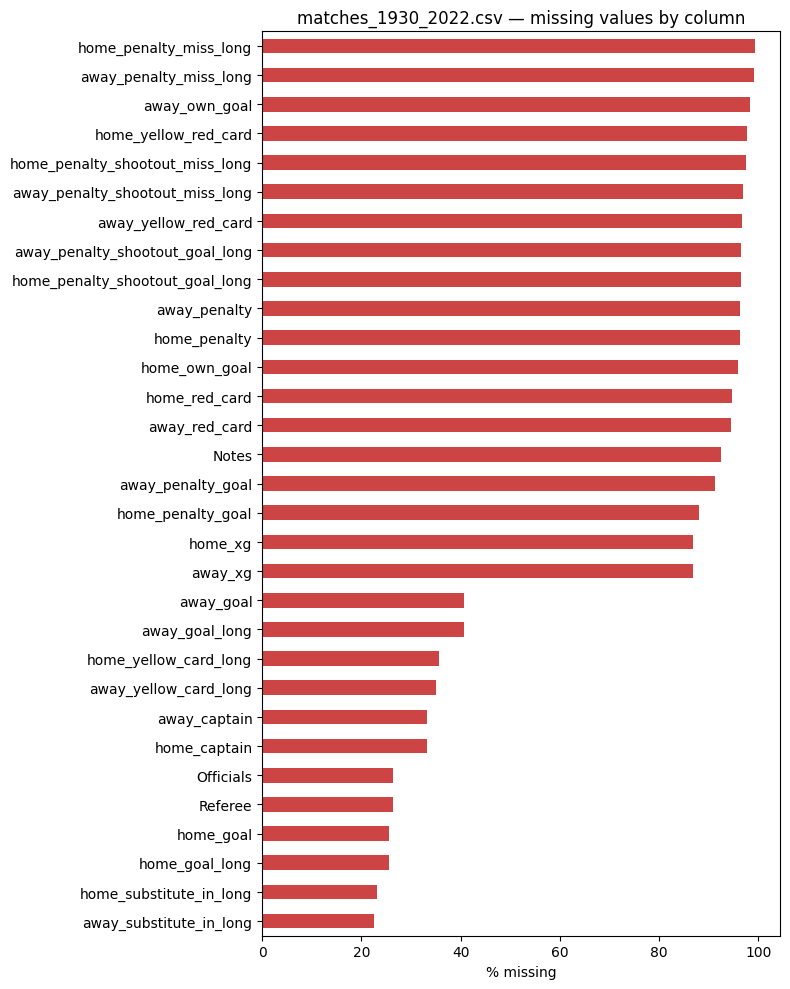

In [7]:
df = frames["kaggle_2026/matches_1930_2022.csv"]
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]

ax = miss.plot.barh(figsize=(8, 10), color="#c44")
ax.invert_yaxis()
ax.set_xlabel("% missing")
ax.set_title("matches_1930_2022.csv — missing values by column")
plt.tight_layout()
plt.show()

## 2.2 Team-name mismatch between sources

The same country is spelled differently across files (e.g. `Iran` vs `IR Iran`). Any join on
raw names would silently drop those rows. This is the problem `src/teams.py` solves — and why
Part 3 uses the clean loaders instead of the raw `frames`.

In [8]:
aliases = {
    "USA": {"usa", "united states"},
    "Iran": {"iran", "ir iran"},
    "South Korea": {"south korea", "korea republic"},
}
team_cols = {
    "team", "home_team", "away_team", "home team", "away team",
    "winner", "runners-up", "runner-up", "champion", "runner_up",
}

found = {k: set() for k in aliases}
for name, df in frames.items():
    cols = [c for c in df.columns if c.lower().strip() in team_cols]
    if not cols:
        continue
    values = pd.concat([df[c].astype(str) for c in cols]).str.strip().dropna().unique()
    for raw in values:
        for canon, accepted in aliases.items():
            if raw.lower() in accepted:
                found[canon].add(raw)

pd.DataFrame({
    "canonical": list(found),
    "spellings_found": [", ".join(sorted(v)) for v in found.values()],
    "inconsistent": [len(v) > 1 for v in found.values()],
})

,canonical,spellings_found,inconsistent
0,USA,"USA, United States",True
1,Iran,"IR Iran, Iran",True
2,South Korea,"Korea Republic, South Korea",True


---
# 3. Insights

From here on we use **`src.load`** — the cleaned loaders that apply the canonical team-name map,
so the two sources line up. These are the questions the data can actually answer for a 2026 model.

In [9]:
# Load the clean tables once; the insight cells below reuse these.
intl = load.load_international()   # all international matches (Maven), names fixed
wc = load.load_wc_matches()        # World Cup finals 1930-2022 (kaggle), names fixed
rankings = load.load_rankings("2026-06-08")  # FIFA ranking before the 2026 cup
squads = load.load_squads()        # 2022 players, with derived non_wc_goals

print("Loaded:")
print(f"  international matches : {len(intl):,}")
print(f"  WC finals matches     : {len(wc):,}")
print(f"  ranked teams          : {len(rankings):,}")
print(f"  2022 squad players    : {len(squads):,}")

Loaded:
  international matches : 17,769
  WC finals matches     : 964
  ranked teams          : 211
  2022 squad players    : 831


## 3.1 How the two sources fit together

Maven's `international_matches` holds qualifiers, friendlies and continental cups — but **not**
the World Cup finals, which live only in the kaggle file. So the two barely overlap: combine
them for full coverage.

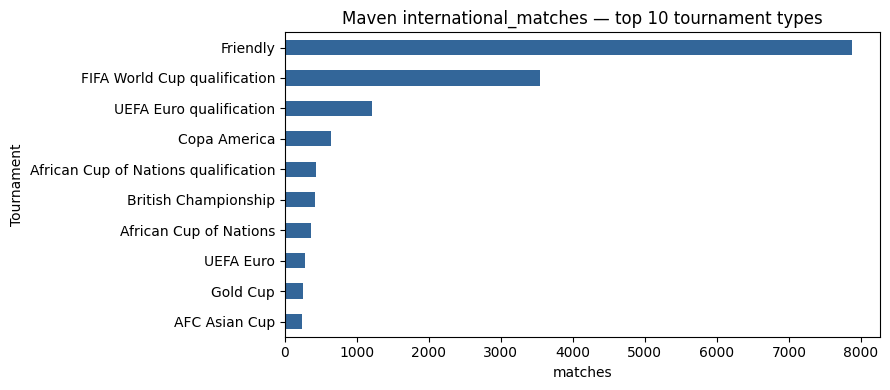

Maven international matches : 17,769  (WC qualifiers: 3,541)
Kaggle WC finals matches    : 964  (1930-2022)
=> finals and non-finals barely overlap: combine them for full coverage.


In [10]:
top_tourneys = intl["Tournament"].value_counts().head(10)
ax = top_tourneys.sort_values().plot.barh(color="#369")
ax.set_title("Maven international_matches — top 10 tournament types")
ax.set_xlabel("matches")
plt.tight_layout()
plt.show()

print(f"Maven international matches : {len(intl):,}  (WC qualifiers: {int(intl['is_wc_qualifier'].sum()):,})")
print(f"Kaggle WC finals matches    : {len(wc):,}  ({wc['Year'].min()}-{wc['Year'].max()})")
print("=> finals and non-finals barely overlap: combine them for full coverage.")

## 3.2 The FIFA ranking landscape (2026 snapshot)

How team strength is distributed going into 2026, and which confederations are strongest
on average.

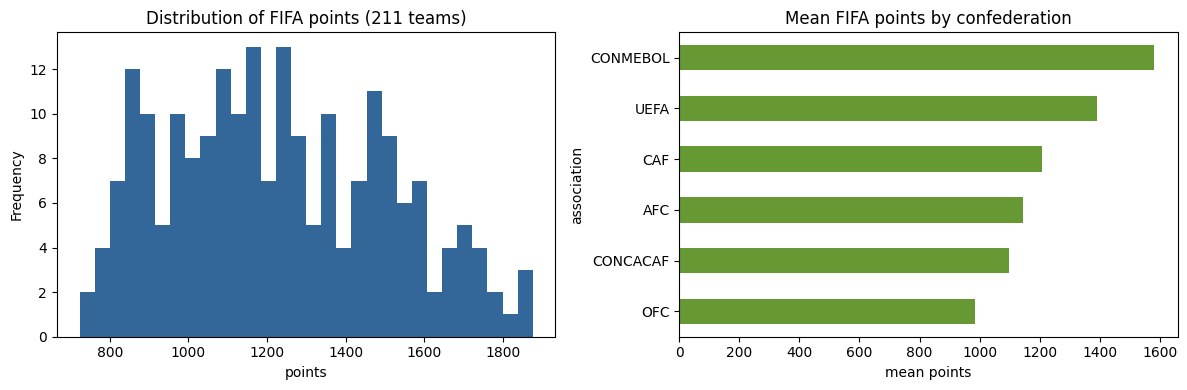

**Current top 10 teams:**

,rank,team,association,points
0,1,Argentina,CONMEBOL,1876.118331
1,2,Spain,UEFA,1873.013187
2,3,France,UEFA,1869.428449
3,4,England,UEFA,1827.048678
4,5,Portugal,UEFA,1766.177547
5,6,Brazil,CONMEBOL,1765.856297
6,7,Morocco,CAF,1755.100232
7,8,Netherlands,UEFA,1751.097835
8,9,Belgium,UEFA,1742.235945
9,10,Germany,UEFA,1735.771984


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
rankings["points"].plot.hist(bins=30, ax=ax1, color="#369")
ax1.set_title("Distribution of FIFA points (211 teams)")
ax1.set_xlabel("points")

rankings.groupby("association")["points"].mean().sort_values().plot.barh(ax=ax2, color="#693")
ax2.set_title("Mean FIFA points by confederation")
ax2.set_xlabel("mean points")
plt.tight_layout()
plt.show()

display(Markdown("**Current top 10 teams:**"))
rankings.sort_values("rank").head(10)[["rank", "team", "association", "points"]]

## 3.3 Recent form vs FIFA ranking (the join in action)

For every team we compute the win rate over their **last 30 international matches** and join it
to the current FIFA ranking. The join works only because names are normalized — this is the
core feature shape for a 2026 model.

> ⚠️ Caveat: Maven's matches end in 2022, so this "recent form" is really *form as of 2022*,
> not mid-2026. You'd refresh it with newer match data before modelling.

Teams joined (form + ranking): 134


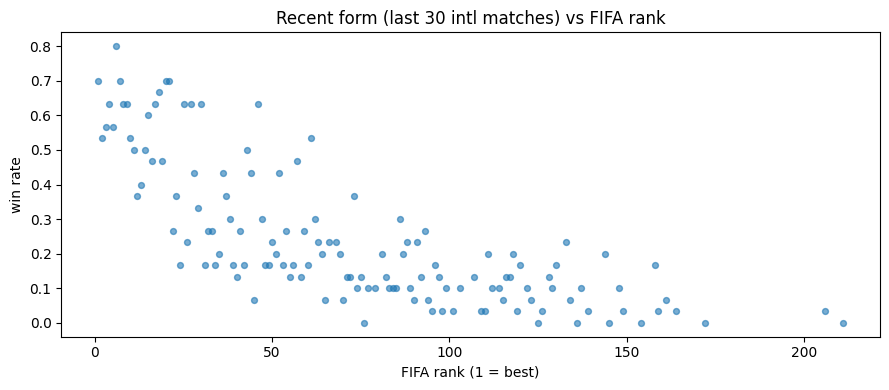

In [12]:
def long_results(df):
    """One row per (team, match) with goals-for / goals-against and a win flag."""
    home = pd.DataFrame({"team": df["Home Team"], "date": df["Date"],
                         "gf": df["Home Goals"], "ga": df["Away Goals"]})
    away = pd.DataFrame({"team": df["Away Team"], "date": df["Date"],
                         "gf": df["Away Goals"], "ga": df["Home Goals"]})
    out = pd.concat([home, away], ignore_index=True).dropna(subset=["date"])
    out["win"] = (out["gf"] > out["ga"]).astype(int)
    return out.sort_values("date")

lr = long_results(intl)

# Win rate over each team's last 30 matches (require a full 30 to be meaningful).
last30 = lr.groupby("team").tail(30)
form = last30.groupby("team").agg(matches=("win", "size"), win_rate=("win", "mean"))
form = form[form["matches"] >= 30]

joined = form.join(rankings.set_index("team")[["rank", "points"]], how="inner")
print(f"Teams joined (form + ranking): {len(joined)}")

ax = joined.plot.scatter(x="rank", y="win_rate", s=18, alpha=0.6)
ax.set_title("Recent form (last 30 intl matches) vs FIFA rank")
ax.set_xlabel("FIFA rank (1 = best)")
ax.set_ylabel("win rate")
plt.tight_layout()
plt.show()

In [13]:
display(Markdown("**Most in-form sides among the FIFA top 50:**"))
joined[joined["rank"] <= 50].sort_values("win_rate", ascending=False).head(10).round(3)

**Most in-form sides among the FIFA top 50:**

,matches,win_rate,rank,points
team,,,,
Brazil,30,0.800,6,1765.856
Argentina,30,0.700,1,1876.118
Denmark,30,0.700,21,1619.474
IR Iran,30,0.700,20,1619.582
Morocco,30,0.700,7,1755.100
Japan,30,0.667,18,1661.576
Canada,30,0.633,30,1559.479
England,30,0.633,4,1827.049
Belgium,30,0.633,9,1742.236


## 3.4 World Cup scoring trends

How goals-per-match and the "home" team's win rate have shifted across tournaments (kaggle
finals data). Remember: at a neutral World Cup, "home" is mostly just a label except for the host.

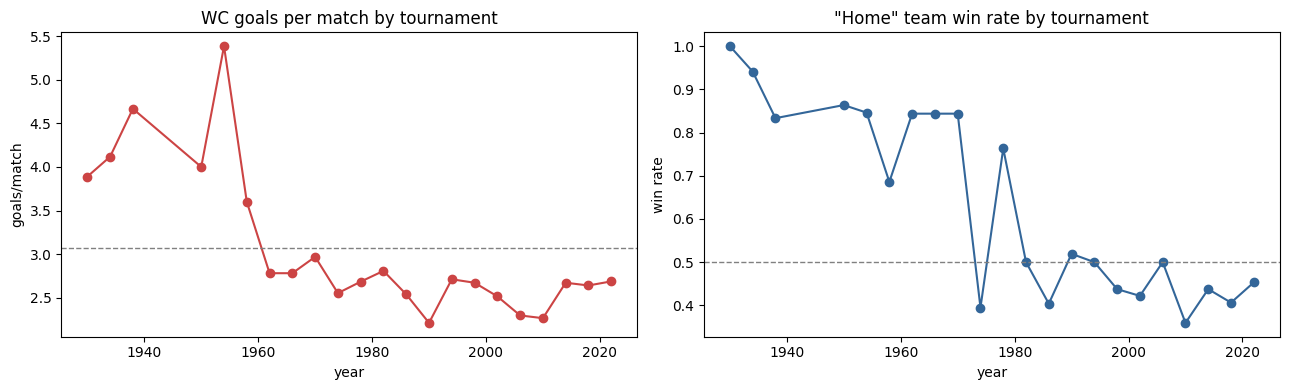

Overall WC goals/match: 2.82


In [14]:
wcc = wc.copy()
wcc["total_goals"] = wcc["home_score"] + wcc["away_score"]
by_year = wcc.groupby("Year").agg(
    goals_per_match=("total_goals", "mean"),
    home_win_rate=("home_score", lambda s: (s > wcc.loc[s.index, "away_score"]).mean()),
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
by_year["goals_per_match"].plot(marker="o", ax=ax1, color="#c44")
ax1.set_title("WC goals per match by tournament")
ax1.set_xlabel("year"); ax1.set_ylabel("goals/match")
ax1.axhline(by_year["goals_per_match"].mean(), ls="--", c="gray", lw=1)

by_year["home_win_rate"].plot(marker="o", ax=ax2, color="#369")
ax2.set_title('"Home" team win rate by tournament')
ax2.set_xlabel("year"); ax2.set_ylabel("win rate")
ax2.axhline(0.5, ls="--", c="gray", lw=1)
plt.tight_layout()
plt.show()

print(f"Overall WC goals/match: {wcc['total_goals'].mean():.2f}")

## 3.5 Squad experience & scorers (2022)

Player-level context the World Cup match data alone can't see. `non_wc_goals` = career
international goals scored **outside** the World Cup (`Goals − WC Goals`).

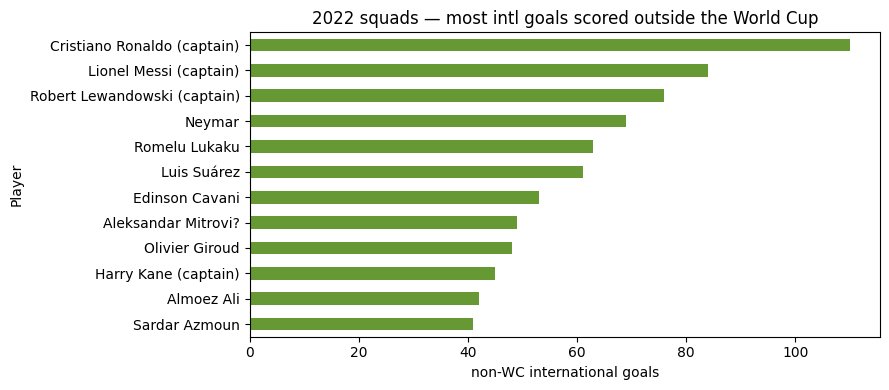

**Most experienced squads (median caps per player):**

,median_caps
Team,
Qatar,53.0
Belgium,40.0
IR Iran,35.0
Mexico,34.0
Canada,31.0
Wales,30.0
Germany,30.0
Switzerland,29.5
Tunisia,29.5


In [15]:
top_scorers = squads.sort_values("non_wc_goals", ascending=False).head(12)
ax = top_scorers.set_index("Player")["non_wc_goals"].iloc[::-1].plot.barh(color="#693")
ax.set_title("2022 squads — most intl goals scored outside the World Cup")
ax.set_xlabel("non-WC international goals")
plt.tight_layout()
plt.show()

display(Markdown("**Most experienced squads (median caps per player):**"))
squads.groupby("Team")["Caps"].median().sort_values(ascending=False).head(12).to_frame("median_caps")

---
## Recap

- **Part 1** — 12 files across 2 sources; kaggle = finals + rankings + 2026 schedule, Maven = full match history + squads.
- **Part 2** — event columns are sparse by design; country names differ across sources (fixed in `src/teams.py`).
- **Part 3** — the cleaned data joins cleanly: ranking vs form, scoring trends, squad experience.

**Next step:** turn the Part 3.3 form logic into reusable features in `src/features.py`, keyed to
`load.load_schedule_2026()`, for a 2026 prediction model.